# Ensemble Variance ($K=50$) + Per-Class KID

This notebook:
1. Runs **50 random seeds** of DiT reverse diffusion for each selected ImageNet class
2. Computes and plots **ensemble variance** $U_{\text{ens}}(t, c)$
3. Saves the **final decoded images** from those seeds and computes **KID vs ImageNet validation** for every class

$$U_{\text{ens}}(t, c) = \mathrm{Var}_k\big[D_0(x_t^{(k)}, t, c)\big]$$

**Note:** All 1000 ImageNet classes × 50 seeds × 250 steps is very expensive. Use the config cell to start with a subset, then set `class_labels = tuple(range(1000))` for the full run. Results are checkpointed so you can resume.

KID (Kernel Inception Distance) is preferred over FID here because each class has only ~50 generated / ~50 real images.


# 1. Setup

In [1]:
%cd ../

/home/sepuhopar/dev/SMILES-Project-27-Uncertainty-in-Diffusion


In [2]:
#!git clone https://github.com/facebookresearch/DiT.git
import DiT, os
os.chdir("DiT")

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from tqdm.auto import tqdm
from torchvision.utils import save_image

from diffusion import create_diffusion
from diffusers.models import AutoencoderKL
from download import find_model
from models import DiT_XL_2

torch.set_grad_enabled(False)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device={device}")
if device == "cpu":
    print("GPU not found. Using CPU instead.")

Multiple distributions found for package optimum. Picked distribution: optimum
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


device=cuda


# 2. Load DiT-XL/2

In [3]:
image_size = 256  #@param [256, 512]
vae_model = "stabilityai/sd-vae-ft-ema"  #@param ["stabilityai/sd-vae-ft-mse", "stabilityai/sd-vae-ft-ema"]
latent_size = int(image_size) // 8

model = DiT_XL_2(input_size=latent_size).to(device)
state_dict = find_model(f"DiT-XL-2-{image_size}x{image_size}.pt")
model.load_state_dict(state_dict)
model.eval()
vae = AutoencoderKL.from_pretrained(vae_model).to(device)
print("Model + VAE ready.")

/home/sepuhopar/miniconda3/envs/ldm/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Model + VAE ready.


# 3. Config

Set `class_labels = tuple(range(1000))` to run **every** ImageNet class.  
Point `IMAGENET_VAL_ROOT` at your ImageNet validation folder (either `val/<wnid>/` or `val/<class_id>/`).

In [26]:
# ---- Ensemble / sampling knobs ----
K = 50  #@param {type:"integer"}  # random seeds per class
ens_cfg_scale = 4.0  #@param {type:"slider", min:1, max:10, step:0.1}
ens_num_sampling_steps = 250  #@param {type:"slider", min:10, max:1000, step:1}
ens_seed_base = 0  #@param {type:"integer"}
patch_size = 2  # DiT-XL/2 latent patch size

# Subset for a quick start (same classes as run_DiT.ipynb).
# For the full ImageNet run, uncomment the next line:
class_labels = tuple(range(1000))
#class_labels = (207, 360, 387, 974, 88, 979, 417, 279 )

# ---- Paths ----
# Expected layouts:
#   IMAGENET_VAL_ROOT/<wnid>/*.JPEG   (standard ILSVRC)
#   IMAGENET_VAL_ROOT/<class_id>/*    (numeric folders 0..999)
IMAGENET_VAL_ROOT = Path("../imagenet_val/val")  #@param {type:"string"}

RESULTS_DIR = Path("../results/ensemble_K50_fid")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SAMPLES_DIR = RESULTS_DIR / "samples"
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = RESULTS_DIR / "checkpoint.pt"
KID_JSON_PATH = RESULTS_DIR / "kid_per_class.json"

ens_diffusion = create_diffusion(str(ens_num_sampling_steps))
shape = (1, 4, latent_size, latent_size)

print(f"K={K}, steps={ens_num_sampling_steps}, cfg={ens_cfg_scale}")
print(f"#classes={len(class_labels)}")
print(f"results -> {RESULTS_DIR.resolve()}")
print(f"ImageNet val root exists: {IMAGENET_VAL_ROOT.exists()} ({IMAGENET_VAL_ROOT})")


K=50, steps=250, cfg=4.0
#classes=1000
results -> /home/sepuhopar/dev/SMILES-Project-27-Uncertainty-in-Diffusion/results/ensemble_K50_fid
ImageNet val root exists: True (../imagenet_val/val)


# 4. Ensemble variance helpers

In [27]:
def x0_to_patch_variance(x0_ensemble, patch_size=2):
    """Per-patch variance of K x0 predictions: (K,C,H,W) -> (H//p, W//p)."""
    var_map = x0_ensemble.var(dim=0)  # (C, H, W)
    c, h, w = var_map.shape
    var_map = var_map.reshape(
        c, h // patch_size, patch_size, w // patch_size, patch_size
    )
    return var_map.mean(dim=(0, 2, 4))


def decode_latents(latents):
    """Decode DiT latents to RGB in [-1, 1]."""
    return vae.decode(latents / 0.18215).sample


def save_uint8_image(tensor_chw, path):
    """Save a single image tensor in [-1, 1] as PNG."""
    x = torch.clamp(127.5 * tensor_chw + 128.0, 0, 255)
    x = x.permute(1, 2, 0).to("cpu", dtype=torch.uint8).numpy()
    Image.fromarray(x).save(path)


def run_ensemble_x0_for_class(class_label, K=50, seed_base=0, progress=True, save_finals_dir=None):
    """Run K full-path samples for one class.

    Returns:
        x0_ensemble: (K, T, C, H, W) predicted x0 along the reverse path
        timestep_bins: list of original diffusion timesteps (len T)
    """
    if save_finals_dir is not None:
        save_finals_dir = Path(save_finals_dir)
        save_finals_dir.mkdir(parents=True, exist_ok=True)

    x0_by_t = []
    timestep_bins = [
        ens_diffusion.timestep_map[i]
        for i in range(ens_diffusion.num_timesteps - 1, -1, -1)
    ]

    iterator = range(K)
    if progress:
        iterator = tqdm(iterator, desc=f"class {class_label}", leave=False)

    for k in iterator:
        torch.manual_seed(seed_base + k)
        z = torch.randn(*shape, device=device)
        z_cfg = torch.cat([z, z], dim=0)
        y = torch.tensor([class_label, 1000], device=device)
        model_kwargs = dict(y=y, cfg_scale=ens_cfg_scale)

        traj = []
        final_latent = None
        for out in ens_diffusion.p_sample_loop_progressive(
            model.forward_with_cfg,
            z_cfg.shape,
            z_cfg,
            clip_denoised=False,
            model_kwargs=model_kwargs,
            device=device,
            progress=False,
        ):
            pred = out["pred_xstart"][:1]
            traj.append(pred.cpu())
            final_latent = out["sample"][:1]

        x0_by_t.append(torch.stack(traj, dim=0))  # (T, 1, C, H, W)

        if save_finals_dir is not None and final_latent is not None:
            img = decode_latents(final_latent)[0]
            save_uint8_image(img, save_finals_dir / f"{k:03d}.png")

    x0_ensemble = torch.stack([x.squeeze(1) for x in x0_by_t], dim=0)  # (K, T, C, H, W)
    return x0_ensemble, timestep_bins


def load_checkpoint(path=CHECKPOINT_PATH):
    if Path(path).exists():
        ckpt = torch.load(path, map_location="cpu", weights_only=False)
        print(f"Loaded checkpoint with {len(ckpt.get('U_ens_mean', {}))} classes.")
        return ckpt
    return {"U_ens_mean": {}, "U_ens_patch": {}, "timestep_bins": None}


def save_checkpoint(U_ens_mean, U_ens_patch, timestep_bins, path=CHECKPOINT_PATH):
    torch.save(
        {
            "U_ens_mean": U_ens_mean,
            "U_ens_patch": U_ens_patch,
            "timestep_bins": timestep_bins,
            "K": K,
            "cfg_scale": ens_cfg_scale,
            "num_sampling_steps": ens_num_sampling_steps,
            "seed_base": ens_seed_base,
            "class_labels": list(class_labels),
        },
        path,
    )


print("Helpers ready.")

Helpers ready.


# 5. Run ensemble variance ($K=50$)

Skips classes already present in the checkpoint so long runs can be resumed.

In [28]:
ckpt = load_checkpoint()
U_ens_mean = ckpt["U_ens_mean"]
U_ens_patch = ckpt["U_ens_patch"]
timestep_bins = ckpt.get("timestep_bins")

pending = [c for c in class_labels if c not in U_ens_mean]
print(f"Already done: {len(class_labels) - len(pending)} / {len(class_labels)}")
print(f"Pending: {len(pending)}")

for class_label in tqdm(pending, desc="classes"):
    class_sample_dir = SAMPLES_DIR / f"class_{class_label:04d}"
    x0_ensemble, timestep_bins = run_ensemble_x0_for_class(
        class_label,
        K=K,
        seed_base=ens_seed_base,
        progress=True,
        save_finals_dir=class_sample_dir,
    )
    num_t = x0_ensemble.shape[1]
    patch_maps = torch.stack(
        [x0_to_patch_variance(x0_ensemble[:, t], patch_size) for t in range(num_t)],
        dim=0,
    )  # (T, ph, pw)

    U_ens_patch[class_label] = patch_maps.numpy()
    U_ens_mean[class_label] = {
        int(timestep_bins[t]): float(patch_maps[t].mean()) for t in range(num_t)
    }

    save_checkpoint(U_ens_mean, U_ens_patch, timestep_bins)
    print(
        f"class {class_label}: saved U_ens + {K} images -> {class_sample_dir} | "
        f"mean U_ens range [{patch_maps.mean(dim=(1, 2)).min():.4f}, "
        f"{patch_maps.mean(dim=(1, 2)).max():.4f}]"
    )

print(f"Done. Checkpoint: {CHECKPOINT_PATH.resolve()}")

Loaded checkpoint with 8 classes.
Already done: 8 / 1000
Pending: 992


classes:   0%|          | 0/992 [00:00<?, ?it/s]

class 0:   0%|          | 0/50 [00:00<?, ?it/s]

class 0: saved U_ens + 50 images -> ../results/ensemble_K50_fid/samples/class_0000 | mean U_ens range [0.0538, 0.7762]


class 1:   0%|          | 0/50 [00:00<?, ?it/s]

...

class 95: saved U_ens + 50 images -> ../results/ensemble_K50_fid/samples/class_0095 | mean U_ens range [0.0480, 0.6378]


class 96:   0%|          | 0/50 [00:00<?, ?it/s]

class 96: saved U_ens + 50 images -> ../results/ensemble_K50_fid/samples/class_0096 | mean U_ens range [0.0386, 1.0878]


class 97:   0%|          | 0/50 [00:00<?, ?it/s]

KeyboardInterrupt: 

# 6. Plot ensemble variance

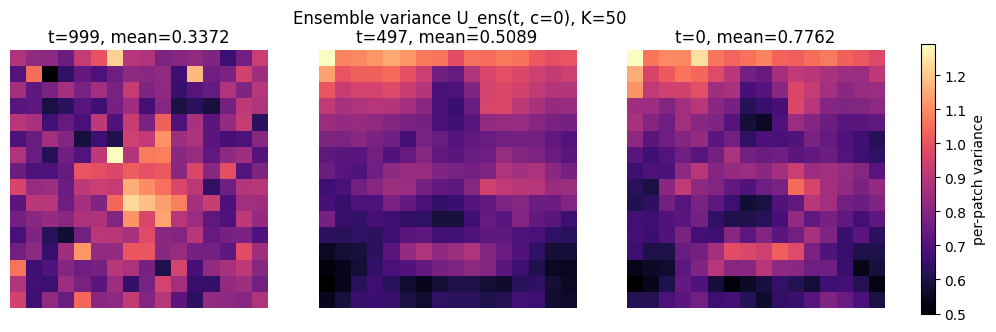

In [29]:
# Per-patch U_ens heatmaps at early / mid / late steps (first finished class)
vis_class = next(c for c in class_labels if c in U_ens_patch)
maps = U_ens_patch[vis_class]
t_labels = list(U_ens_mean[vis_class].keys())
t_show = [0, len(maps) // 2, len(maps) - 1]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, ti in zip(axes, t_show):
    im = ax.imshow(maps[ti], cmap="magma")
    ax.set_title(f"t={t_labels[ti]}, mean={maps[ti].mean():.4f}")
    ax.axis("off")
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.04, label="per-patch variance")
fig.suptitle(f"Ensemble variance U_ens(t, c={vis_class}), K={K}")
plt.show()
fig.savefig(RESULTS_DIR / f"uens_heatmap_class_{vis_class}.png", dpi=150, bbox_inches="tight")

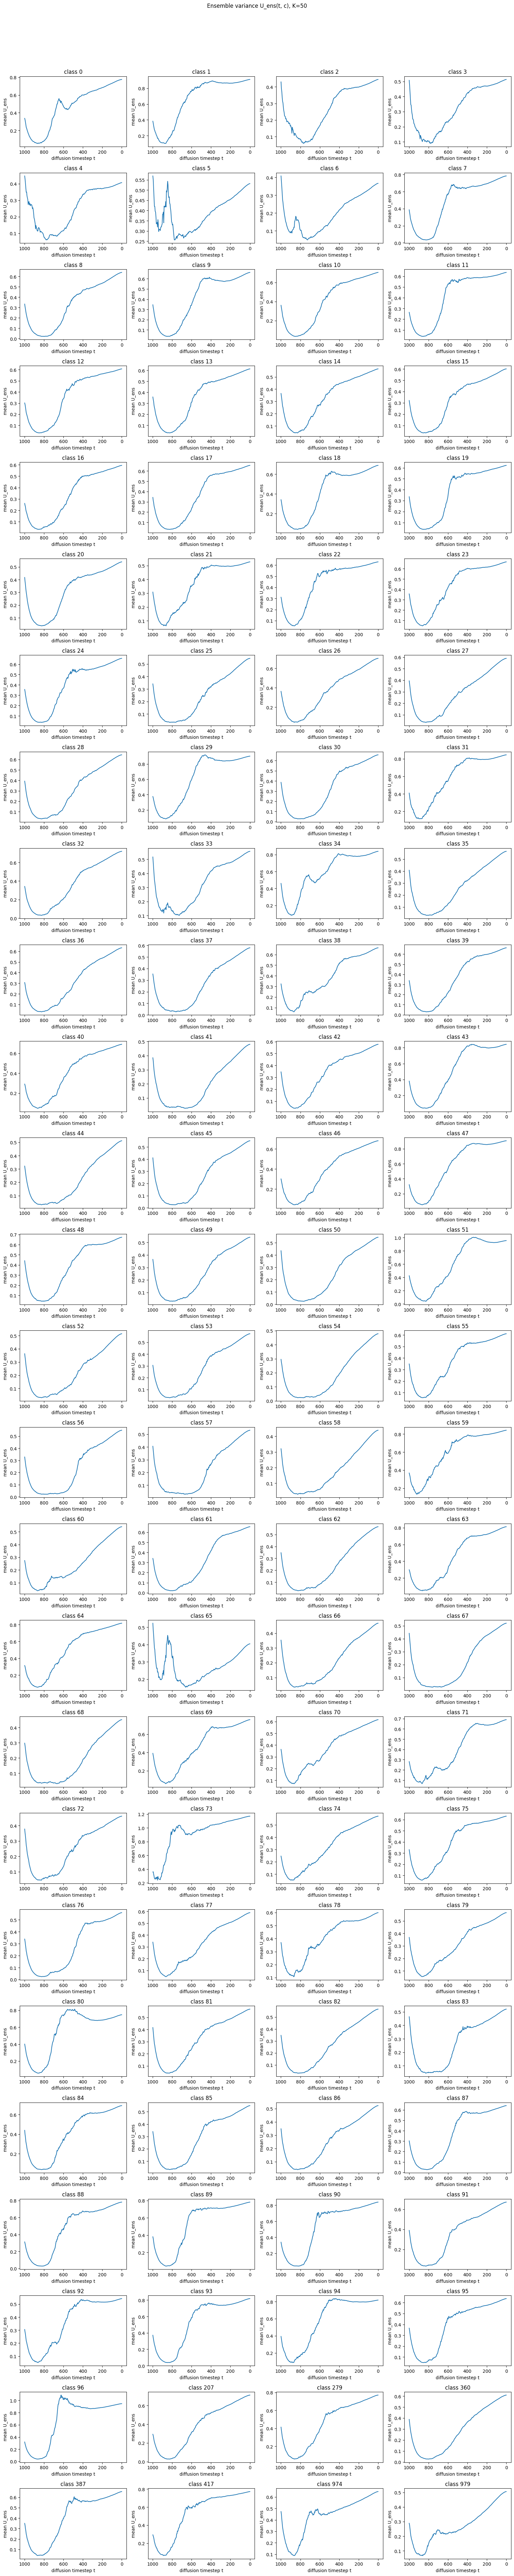

In [30]:
# U_ens(t) profiles for every finished class
classes = [c for c in class_labels if c in U_ens_mean]
n_classes = len(classes)
assert n_classes > 0, "No finished classes yet — run the ensemble cell first."

ncols = min(4, n_classes)
nrows = int(math.ceil(n_classes / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False)

for ax, class_label in zip(axes.flat, classes):
    ts = list(U_ens_mean[class_label].keys())
    vals = list(U_ens_mean[class_label].values())
    ax.plot(ts, vals)
    ax.invert_xaxis()  # 999 -> 0 as denoising progresses
    ax.set_title(f"class {class_label}")
    ax.set_xlabel("diffusion timestep t")
    ax.set_ylabel("mean U_ens")

for ax in axes.flat[n_classes:]:
    ax.axis("off")

fig.suptitle(f"Ensemble variance U_ens(t, c), K={K}", y=1.02)
plt.tight_layout()
plt.show()
fig.savefig(RESULTS_DIR / "uens_profiles.png", dpi=150, bbox_inches="tight")

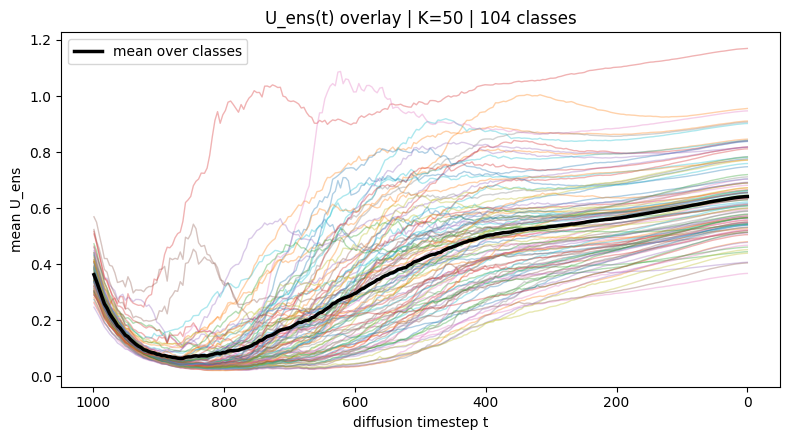

In [31]:
# Overlay all classes on one axis + mean profile
fig, ax = plt.subplots(figsize=(8, 4.5))
all_vals = []
for class_label in classes:
    ts = list(U_ens_mean[class_label].keys())
    vals = list(U_ens_mean[class_label].values())
    ax.plot(ts, vals, alpha=0.35, linewidth=1)
    all_vals.append(vals)

mean_profile = np.mean(np.stack(all_vals, axis=0), axis=0)
ax.plot(ts, mean_profile, color="black", linewidth=2.5, label="mean over classes")
ax.invert_xaxis()
ax.set_xlabel("diffusion timestep t")
ax.set_ylabel("mean U_ens")
ax.set_title(f"U_ens(t) overlay | K={K} | {len(classes)} classes")
ax.legend()
plt.tight_layout()
plt.show()
fig.savefig(RESULTS_DIR / "uens_overlay.png", dpi=150, bbox_inches="tight")

# 7. Per-class KID on ImageNet validation (clean-fid)

Uses the **same $K=50$ final samples** saved above as generated images, compared against real ImageNet validation images of that class via [`clean-fid`](https://github.com/GaParmar/clean-fid) (`compute_kid`).

Requires `IMAGENET_VAL_ROOT` to point at a valid ImageNet `val` directory.


In [32]:
# !pip install clean-fid  # uncomment if needed
import urllib.request
from cleanfid import fid as clean_fid


def load_imagenet_wnids():
    """Return list of 1000 ImageNet synset ids in torchvision/class-index order."""
    url = (
        "https://raw.githubusercontent.com/raghakot/keras-vis/master/resources/"
        "imagenet_class_index.json"
    )
    cache = RESULTS_DIR / "imagenet_class_index.json"
    if not cache.exists():
        urllib.request.urlretrieve(url, cache)
    with open(cache) as f:
        idx = json.load(f)
    # idx["0"] = ["n01440764", "tench"], ...
    return [idx[str(i)][0] for i in range(1000)]


def resolve_val_class_dir(class_id, val_root=IMAGENET_VAL_ROOT, wnids=None):
    """Find the validation folder for an ImageNet class id."""
    val_root = Path(val_root)
    candidates = [
        val_root / str(class_id),
        val_root / f"{class_id:04d}",
        val_root / f"{class_id:03d}",
    ]
    if wnids is not None:
        candidates.append(val_root / wnids[class_id])
    for path in candidates:
        if path.is_dir() and any(path.iterdir()):
            return path
    return None


def count_images(folder):
    exts = {".png", ".jpg", ".jpeg", ".JPEG", ".PNG", ".JPG"}
    return sum(1 for p in Path(folder).iterdir() if p.suffix in exts)


def compute_clean_kid(gen_dir, real_dir, batch_size=32):
    """KID between two image folders using clean-fid (mode='clean')."""
    return float(
        clean_fid.compute_kid(
            fdir1=str(gen_dir),
            fdir2=str(real_dir),
            mode="clean",
            device=torch.device(device),
            batch_size=batch_size,
            num_workers=0,
            verbose=False,
            use_dataparallel=False,
        )
    )


assert IMAGENET_VAL_ROOT.exists(), (
    f"Set IMAGENET_VAL_ROOT to your ImageNet val folder (got {IMAGENET_VAL_ROOT})"
)

wnids = load_imagenet_wnids()
print(f"Example val dir for class 207: {resolve_val_class_dir(207, wnids=wnids)}")
print("Metric backend: clean-fid KID (mode=clean)")


Example val dir for class 207: ../imagenet_val/val/n02099601
Metric backend: clean-fid KID (mode=clean)


In [33]:
# Load any previously computed KID values so we can resume
if KID_JSON_PATH.exists():
    with open(KID_JSON_PATH) as f:
        kid_per_class = {int(k): v for k, v in json.load(f).items()}
else:
    kid_per_class = {}

kid_classes = [c for c in class_labels if c in U_ens_mean]
pending_kid = [c for c in kid_classes if c not in kid_per_class]
print(f"KID already done: {len(kid_classes) - len(pending_kid)} / {len(kid_classes)}")
print(f"KID pending: {len(pending_kid)}")

for class_label in tqdm(pending_kid, desc="KID (clean-fid)"):
    gen_dir = SAMPLES_DIR / f"class_{class_label:04d}"
    real_dir = resolve_val_class_dir(class_label, wnids=wnids)
    if real_dir is None:
        print(f"class {class_label}: SKIP — no val folder found under {IMAGENET_VAL_ROOT}")
        continue
    n_gen = count_images(gen_dir)
    n_real = count_images(real_dir)
    if n_gen < 2 or n_real < 2:
        print(f"class {class_label}: SKIP — need ≥2 images (gen={n_gen}, real={n_real})")
        continue

    kid_val = compute_clean_kid(gen_dir, real_dir, batch_size=32)
    kid_per_class[class_label] = {
        "kid": kid_val,
        "backend": "clean-fid",
        "mode": "clean",
        "n_generated": n_gen,
        "n_real": n_real,
        "gen_dir": str(gen_dir),
        "real_dir": str(real_dir),
    }
    with open(KID_JSON_PATH, "w") as f:
        json.dump({str(k): v for k, v in sorted(kid_per_class.items())}, f, indent=2)
    print(f"class {class_label}: KID={kid_val:.6f} (gen={n_gen}, real={n_real})")

print(f"Saved KID results -> {KID_JSON_PATH.resolve()}")


KID already done: 8 / 104
KID pending: 96


KID (clean-fid):   0%|          | 0/96 [00:00<?, ?it/s]

class 0: KID=0.013490 (gen=50, real=50)
class 1: KID=0.043627 (gen=50, real=50)
class 2: KID=0.011730 (gen=50, real=50)
class 3: KID=0.038447 (gen=50, real=50)
class 4: KID=0.035253 (gen=50, real=50)
class 5: KID=0.035962 (gen=50, real=50)
class 6: KID=0.047339 (gen=50, real=50)
class 7: KID=0.034466 (gen=50, real=50)
class 8: KID=0.041404 (gen=50, real=50)
class 9: KID=0.030949 (gen=50, real=50)
class 10: KID=0.031450 (gen=50, real=50)
class 11: KID=0.015607 (gen=50, real=50)
class 12: KID=0.019660 (gen=50, real=50)
class 13: KID=0.006811 (gen=50, real=50)
class 14: KID=0.007856 (gen=50, real=50)
class 15: KID=0.009660 (gen=50, real=50)
class 16: KID=0.029268 (gen=50, real=50)
class 17: KID=0.013889 (gen=50, real=50)
class 18: KID=0.020592 (gen=50, real=50)
class 19: KID=0.008512 (gen=50, real=50)
class 20: KID=0.016448 (gen=50, real=50)
class 21: KID=0.056883 (gen=50, real=50)
class 22: KID=0.005183 (gen=50, real=50)
class 23: KID=0.012791 (gen=50, real=50)
class 24: KID=0.005252 (ge

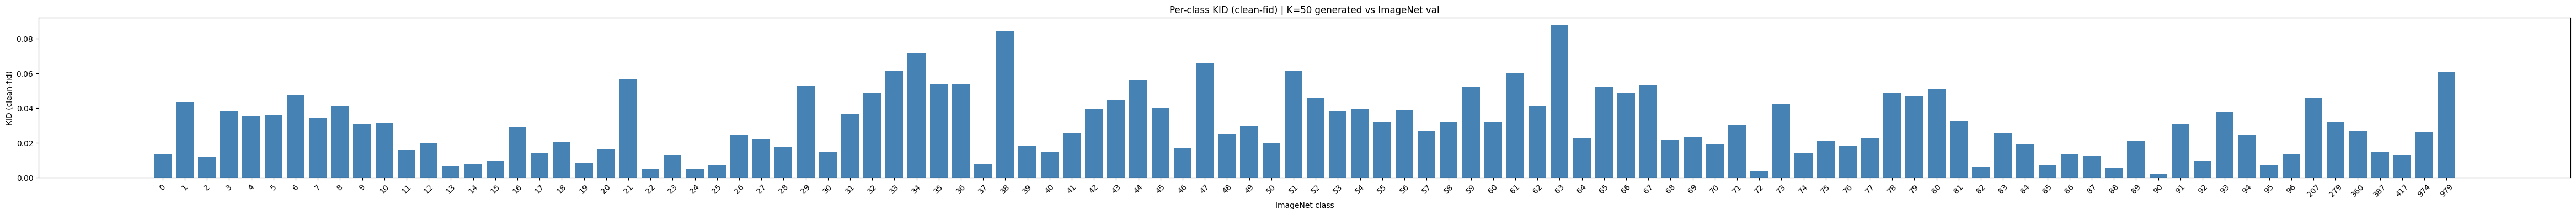

   class           KID   n_gen  n_real
------------------------------------------
       0      0.013490      50      50
       1      0.043627      50      50
       2      0.011730      50      50
       3      0.038447      50      50
       4      0.035253      50      50
       5      0.035962      50      50
       6      0.047339      50      50
       7      0.034466      50      50
       8      0.041404      50      50
       9      0.030949      50      50
      10      0.031450      50      50
      11      0.015607      50      50
      12      0.019660      50      50
      13      0.006811      50      50
      14      0.007856      50      50
      15      0.009660      50      50
      16      0.029268      50      50
      17      0.013889      50      50
      18      0.020592      50      50
      19      0.008512      50      50
      20      0.016448      50      50
      21      0.056883      50      50
      22      0.005183      50      50
      23      0.01279

In [34]:
# KID bar chart + table
kid_classes_done = sorted(kid_per_class.keys())
assert kid_classes_done, "No KID values yet — set IMAGENET_VAL_ROOT and run the KID cell."

kids = [kid_per_class[c]["kid"] for c in kid_classes_done]
fig, ax = plt.subplots(figsize=(max(6, 0.45 * len(kid_classes_done)), 4))
ax.bar([str(c) for c in kid_classes_done], kids, color="steelblue")
ax.set_xlabel("ImageNet class")
ax.set_ylabel("KID (clean-fid)")
ax.set_title(f"Per-class KID (clean-fid) | K={K} generated vs ImageNet val")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
fig.savefig(RESULTS_DIR / "kid_per_class.png", dpi=150, bbox_inches="tight")

print(f"{'class':>8}  {'KID':>12}  {'n_gen':>6}  {'n_real':>6}")
print("-" * 42)
for c in kid_classes_done:
    d = kid_per_class[c]
    print(f"{c:8d}  {d['kid']:12.6f}  {d['n_generated']:6d}  {d['n_real']:6d}")
print("-" * 42)
print(f"mean KID over {len(kids)} classes: {np.mean(kids):.6f}")


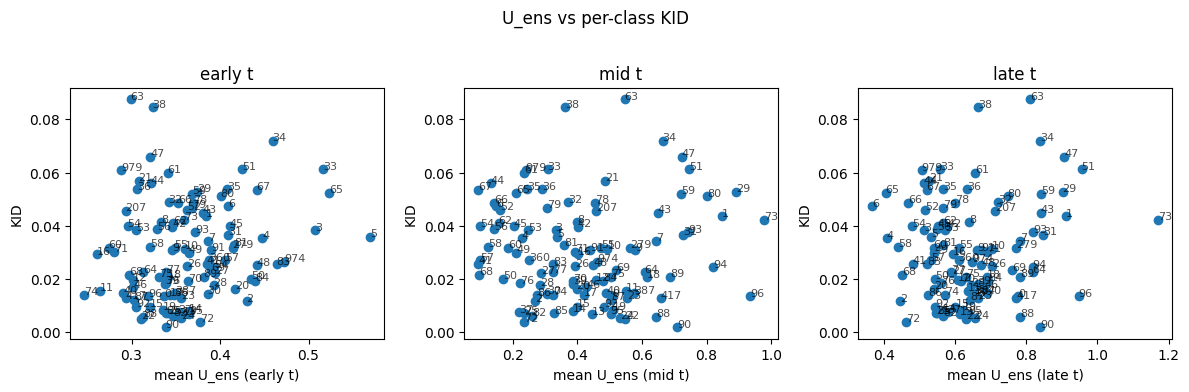

In [35]:
# Optional: correlate mean U_ens (early / late) with KID
rows = []
for c in kid_classes_done:
    if c not in U_ens_mean:
        continue
    ts = list(U_ens_mean[c].keys())
    vals = list(U_ens_mean[c].values())
    mid = len(vals) // 2
    rows.append(
        {
            "class": c,
            "kid": kid_per_class[c]["kid"],
            "uens_early": vals[0],
            "uens_mid": vals[mid],
            "uens_late": vals[-1],
            "uens_mean": float(np.mean(vals)),
        }
    )

if rows:
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
    for ax, key, title in zip(
        axes,
        ["uens_early", "uens_mid", "uens_late"],
        ["early t", "mid t", "late t"],
    ):
        x = [r[key] for r in rows]
        y = [r["kid"] for r in rows]
        ax.scatter(x, y)
        for r in rows:
            ax.annotate(str(r["class"]), (r[key], r["kid"]), fontsize=8, alpha=0.7)
        ax.set_xlabel(f"mean U_ens ({title})")
        ax.set_ylabel("KID")
        ax.set_title(title)
    fig.suptitle("U_ens vs per-class KID", y=1.02)
    plt.tight_layout()
    plt.show()
    fig.savefig(RESULTS_DIR / "uens_vs_kid.png", dpi=150, bbox_inches="tight")


In [ ]:
# 8. Class difficulty tiers by KID

Rank every class that has a computed KID (clean-fid, generated vs. ImageNet val). A **higher KID means the generated
distribution matches the real class distribution less well**, i.e. the class is **harder** for the model. We split
the ranked classes into the **15 hardest** (highest KID), **15 medium** (middle of the ranking), and **15 easiest**
(lowest KID).

In [ ]:
# Human-readable class names
with open(RESULTS_DIR / "imagenet_class_index.json") as f:
    _idx = json.load(f)
class_names = {i: _idx[str(i)][1] for i in range(len(_idx))}

# Rank all classes with a computed KID: highest KID = hardest, lowest KID = easiest
kid_classes_done = sorted(kid_per_class.keys())
assert kid_classes_done, "No KID values yet — run the KID computation cell first."

kid_ranked = sorted(kid_classes_done, key=lambda c: kid_per_class[c]["kid"], reverse=True)
n_ranked = len(kid_ranked)
TIER_SIZE = min(15, n_ranked // 3 if n_ranked >= 3 else n_ranked)

highest_classes = kid_ranked[:TIER_SIZE]  # hardest: highest KID
lowest_classes = kid_ranked[-TIER_SIZE:] if TIER_SIZE > 0 else []  # easiest: lowest KID
mid_start = max(0, n_ranked // 2 - TIER_SIZE // 2)
medium_classes = kid_ranked[mid_start: mid_start + TIER_SIZE]  # medium: middle of the ranking

tiers = {
    "Hardest (highest KID)": highest_classes,
    "Medium KID": medium_classes,
    "Easiest (lowest KID)": lowest_classes,
}

print(f"Ranked {n_ranked} classes by KID | tier size = {TIER_SIZE}\n")
for tier_name, cls_list in tiers.items():
    print(f"=== {tier_name} — {len(cls_list)} classes ===")
    for rank, c in enumerate(cls_list, 1):
        print(f"  #{rank:>2}  class {c:>4}  KID={kid_per_class[c]['kid']:.6f}  {class_names.get(c, '?')}")
    print()

In [ ]:
# Bar chart of the three tiers, colored by difficulty
tier_colors = {
    "Hardest (highest KID)": "crimson",
    "Medium KID": "goldenrod",
    "Easiest (lowest KID)": "seagreen",
}

fig, ax = plt.subplots(figsize=(max(10, 0.4 * 3 * TIER_SIZE), 5))
x = 0
xticks, xlabels = [], []
for tier_name, cls_list in tiers.items():
    vals = [kid_per_class[c]["kid"] for c in cls_list]
    xs = list(range(x, x + len(cls_list)))
    ax.bar(xs, vals, color=tier_colors[tier_name], label=f"{tier_name} (n={len(cls_list)})")
    xticks += xs
    xlabels += [str(c) for c in cls_list]
    x += len(cls_list) + 2

ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, rotation=90, fontsize=7)
ax.set_xlabel("ImageNet class id")
ax.set_ylabel("KID (clean-fid)")
ax.set_title(f"Per-class KID difficulty tiers ({TIER_SIZE} hardest / {TIER_SIZE} medium / {TIER_SIZE} easiest)")
ax.legend()
plt.tight_layout()
plt.show()
fig.savefig(RESULTS_DIR / "kid_difficulty_tiers.png", dpi=150, bbox_inches="tight")

# 9. Sample generated images per class (3 per class)

For each tier (hardest / medium / easiest), show **3 generated samples** for every class, taken from the saved
$K=50$ finals in `SAMPLES_DIR/class_XXXX/`. Each row is one class, labeled with its class id, KID, and name.

In [ ]:
def plot_class_samples(cls_list, tier_name, n_images=3, save_name=None):
    """Plot an (n_classes x n_images) grid of saved generated samples for a tier of classes."""
    n_classes = len(cls_list)
    fig, axes = plt.subplots(
        n_classes, n_images, figsize=(n_images * 2.3, n_classes * 2.3), squeeze=False
    )

    for row, c in enumerate(cls_list):
        class_dir = SAMPLES_DIR / f"class_{c:04d}"
        img_paths = sorted(class_dir.glob("*.png"))[:n_images]
        kid_val = kid_per_class[c]["kid"]
        for col in range(n_images):
            ax = axes[row][col]
            if col < len(img_paths):
                ax.imshow(Image.open(img_paths[col]))
            ax.set_xticks([])
            ax.set_yticks([])
            if col == 0:
                ax.set_ylabel(
                    f"class {c}\n{class_names.get(c, '?')}\nKID={kid_val:.4f}",
                    fontsize=8, rotation=0, labelpad=55, va="center", ha="right",
                )

    fig.suptitle(f"{tier_name}: 3 generated samples per class", y=1.0, fontsize=14)
    plt.tight_layout()
    plt.show()
    if save_name:
        fig.savefig(RESULTS_DIR / save_name, dpi=150, bbox_inches="tight")
    return fig


print("plot_class_samples() ready.")

In [ ]:
_ = plot_class_samples(
    highest_classes, "Hardest classes (highest KID)", n_images=3,
    save_name="samples_grid_hardest.png",
)

In [ ]:
_ = plot_class_samples(
    medium_classes, "Medium classes (mid-range KID)", n_images=3,
    save_name="samples_grid_medium.png",
)

In [ ]:
_ = plot_class_samples(
    lowest_classes, "Easiest classes (lowest KID)", n_images=3,
    save_name="samples_grid_easiest.png",
)